In [1]:
import pandas as pd 
import mysql.connector

In [4]:
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="11649872@MySQL",
    database="temp"
)  

In [8]:
df = pd.read_sql_query("""
 SELECT * FROM 
                (SELECT CONCAT("Match-" , ROW_NUMBER() OVER(ORDER BY ID)) as 'Match_no' ,
                        SUM(batsman_run) as 'Runs_Scored' ,
                        SUM(SUM(batsman_run)) OVER w as 'Career_Runs' ,
                        AVG(SUM(batsman_run)) OVER w as 'Cumulative_Average_Runs' ,
                        AVG(SUM(batsman_run)) OVER(ORDER BY ID ROWS BETWEEN 9 PRECEDING AND CURRENT ROW) as 'Running_Average_Runs'
                FROM temp.ipl_complete
                WHERE batter = 'V Kohli' 
                GROUP BY ID 
                WINDOW w as (ORDER BY ID ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW)      -- useful when  
                ) t
""" , conn)

C:\Users\RITESH\AppData\Local\Temp\ipykernel_2292\1516494042.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query("""


In [9]:
df.head()

,Match_no,Runs_Scored,Career_Runs,Cumulative_Average_Runs,Running_Average_Runs
0,Match-1,1.0,1.0,1.0000,1.0000
1,Match-2,23.0,24.0,12.0000,12.0000
2,Match-3,13.0,37.0,12.3333,12.3333
3,Match-4,12.0,49.0,12.2500,12.2500
4,Match-5,1.0,50.0,10.0000,10.0000


In [7]:
import matplotlib.pyplot as plt

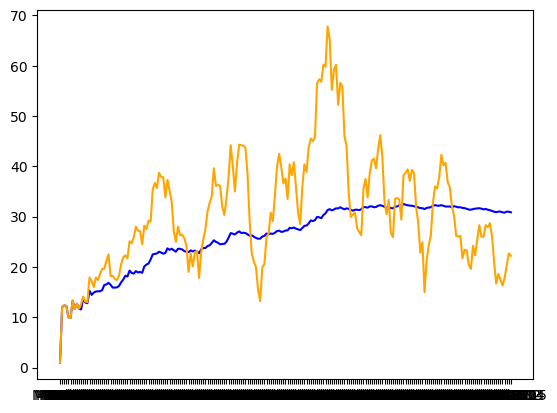

In [11]:
plt.plot(df['Match_no'], df['Cumulative_Average_Runs'], label='Cumulative Average Runs', color='blue')
plt.plot(df['Match_no'], df['Running_Average_Runs'], label='Running Average Runs', color='orange')